Deep Q-Network Learning

In [9]:
import torch
import numpy as np
import time, random
import torch.nn as nn
import gymnasium as gym
from collections import deque
import torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
device

device(type='cpu')

In [12]:
@dataclass
class Config:
    env_id: str = "CartPole-v1"
    total_steps: int = 150_000
    buffer_size: int = 200_000
    batch_size: int = 128
    gamma: float = 0.99
    lr: float = 3e-4
    hidden: int = 256
    learning_starts: int = 1_000
    train_every: int = 1
    tau: float = 0.005
    eps_start: float = 1.0
    eps_end: float = 0.01
    eps_decay_steps: int = 10_000
    eval_window: int = 100
    max_grad_norm: float = 10.0
    solve_threshold: float = 475.0
    obs_norm: bool = True
    adam_eps: float = 1e-4
    n_step: int = 3

CFG = Config()
Q_CEILING = (1 - CFG.gamma ** 500)/(1 - CFG.gamma)

In [13]:
Q_CEILING

99.34295169575846

Replay Buffer

In [14]:
class ReplayBuffer:
    def __init__(self, capacity: int, obs_dim: int):
        self.capacity = capacity
        self.states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros(capacity, dtype=np.int64)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.next_states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.terminated = np.zeros(capacity, dtype=np.float32)
        self.n_steps = np.zeros(capacity, dtype=np.float32)
        self.pos = 0
        self.size = 0

    def add(self, state, action, reward, next_state, terminated, n_steps=1.0):
        i = self.pos
        self.states[i] = state
        self.actions[i] = action
        self.rewards[i] = reward
        self.next_states[i] = next_state
        self.terminated[i] = terminated
        self.n_steps[i] = n_steps
        self.pos = (self.pos + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int):
        idx = np.random.randint(0, self.size, size=batch_size)
        pick = lambda arr, dtype: torch.as_tensor(arr[idx], dtype=dtype, device=device)
        return (
            pick(self.states, torch.float32),
            pick(self.actions, torch.int64),
            pick(self.rewards, torch.float32),
            pick(self.next_states, torch.float32),
            pick(self.terminated, torch.float32),
            pick(self.n_steps, torch.float32)
        )

    def __len__(self):
        return self.size

Q-Network and Epsilon Schedule

In [15]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim: int, n_actions: int, n_hidden: int):
        super().__init__()
        # Shared feature extractor
        self.feature_layer = nn.Sequential(
            nn.Linear(obs_dim, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_hidden),
            nn.ReLU()
        )

        # Value stream: V(s)
        self.value_stream = nn.Linear(n_hidden, 1)

        # Advantage stream: A(s, a)
        self.advantage_stream = nn.Linear(n_hidden, n_actions)

    def forward(self, x):
        features = self.feature_layer(x)
        value = self.value_stream(features)
        advantages = self.advantage_stream(features)

        # Combine using the stable Dueling formula: Q(s,a) = V(s) + (A(s,a) - Mean(A(s,a)))
        q_values = value + (advantages - advantages.mean(dim=1, keepdim=True))
        return q_values

Epsilon Decay

In [16]:
def epsilon_at(step: int, cfg: Config) -> float:
    frac = min(step / cfg.eps_decay_steps, 1.0)
    return cfg.eps_start + frac * (cfg.eps_end - cfg.eps_start)

Training Loop

In [17]:
OBS_SCALE = np.array([2.4, 2.5, 0.2095, 2.5], dtype=np.float32)

def n_step_transition(window, gamma):
    ret = 0.0
    for i, (_, _, r, s2, term) in enumerate(window):
        ret += (gamma ** i) * r
        if term:
            return window[0][0], window[0][1], ret, s2, 1.0, i + 1
    return window[0][0], window[0][1], ret, window[-1][3], 0.0, len(window)

def train(seed: int, config: Config, log_every: int = 500):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env = gym.make(config.env_id)
    env.action_space.seed(seed=seed)

    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    scale = OBS_SCALE if config.obs_norm else np.ones(obs_dim, dtype=np.float32)
    prep = lambda o: np.asarray(o, dtype=np.float32) / scale

    raw_obs, _ = env.reset(seed=seed)
    obs = prep(raw_obs)

    q_net = QNetwork(obs_dim, n_actions, config.hidden).to(device)
    target_net = QNetwork(obs_dim, n_actions, config.hidden).to(device)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = torch.optim.Adam(q_net.parameters(), lr=config.lr, eps=config.adam_eps)
    buffer = ReplayBuffer(config.buffer_size, obs_dim)
    window = deque(maxlen=config.n_step)

    keys = ("step", "return", "epsilon", "mean_q", "td_error", "buffer_size", "updates_per_step", "infer_ms")
    history = {k: [] for k in keys}
    returns, ep_return, grad_steps, solved_at = [], 0.0, 0, None
    recent_q, recent_td, latencies = [], [], []

    for step in range(1, config.total_steps + 1):
        eps = epsilon_at(step, config)

        if random.random() < eps:
            action = int(env.action_space.sample())
        else:
            t0 = time.perf_counter()
            with torch.no_grad():
                state_t = torch.as_tensor(obs, dtype=torch.float32, device=device)
                q_values = q_net(state_t.unsqueeze(0))
            latencies.append((time.perf_counter() - t0) * 1e3)
            action = int(q_values.argmax(dim=1).item())

        next_raw, reward, terminated, truncated, _ = env.step(action)
        next_obs = prep(next_raw)
        ep_return += reward

        window.append((obs, action, float(reward), next_obs, float(terminated)))
        if len(window) == config.n_step:
            buffer.add(*n_step_transition(window, config.gamma))

        obs = next_obs

        if terminated or truncated:
            # Tail flush for n-step
            if len(window) == config.n_step:
                window.popleft()
            while window:
                buffer.add(*n_step_transition(window, config.gamma))
                window.popleft()

            returns.append(ep_return)
            ep_return = 0.0
            raw_obs, _ = env.reset()
            obs = prep(raw_obs)

        if len(buffer) >= config.learning_starts and step % config.train_every == 0:
            states, actions, rewards, next_states, dones, n_steps = buffer.sample(config.batch_size)

            with torch.no_grad():
                best_actions = q_net(next_states).argmax(dim=1).unsqueeze(1)
                next_q = target_net(next_states).gather(1, best_actions).squeeze(1)
                targets = rewards + (config.gamma ** n_steps) * (1.0 - dones) * next_q

            pred = q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
            loss = F.smooth_l1_loss(pred, targets)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(q_net.parameters(), config.max_grad_norm)
            optimizer.step()
            grad_steps += 1

            with torch.no_grad():
                for p, p_t in zip(q_net.parameters(), target_net.parameters()):
                    p_t.data.mul_(1 - config.tau).add_(p.data, alpha=config.tau)

            if step % 10 == 0:
                recent_q.append(pred.mean().item())
                recent_td.append((targets - pred).abs().mean().item())

        if solved_at is None and len(returns) >= config.eval_window and np.mean(returns[-config.eval_window:]) >= config.solve_threshold:
            solved_at = step
            print(f"  [Seed {seed}] Solved at step {step}!")
            break

        if step % log_every == 0:
            window_ret = returns[-config.eval_window:]
            history["step"].append(step)
            history["return"].append(float(np.mean(window_ret)) if window_ret else 0.0)
            history["epsilon"].append(eps)
            history["mean_q"].append(float(np.mean(recent_q)) if recent_q else 0.0)
            history["td_error"].append(float(np.mean(recent_td)) if recent_td else 0.0)
            history["buffer_size"].append(len(buffer))
            history["updates_per_step"].append(grad_steps / step)
            history["infer_ms"].append(float(np.mean(latencies[-1000:])) if latencies else 0.0)
            recent_q.clear()
            recent_td.clear()
    env.close()
    return {"seed": seed, "history": history, "returns": returns, "solved_at": solved_at, "q_net": q_net}

In [18]:
SEEDS = [0, 1, 2]
results = []

for seed in SEEDS:
    t0 = time.perf_counter()
    res = train(seed, CFG)
    res["wall_s"] = time.perf_counter() - t0
    results.append(res)
    final = np.mean(res["returns"][-CFG.eval_window:])
    solved = res["solved_at"] if res["solved_at"] else "not solved"
    print(f"seed {seed}: final-100 return {final:6.1f} | solved at {solved} "
          f"| {res['wall_s']/60:.1f} min | {len(res['returns'])} episodes")

  [Seed 0] Solved at step 133003!
seed 0: final-100 return  477.2 | solved at 133003 | 15.0 min | 493 episodes
  [Seed 1] Solved at step 62840!
seed 1: final-100 return  477.2 | solved at 62840 | 6.9 min | 282 episodes
  [Seed 2] Solved at step 76684!
seed 2: final-100 return  475.3 | solved at 76684 | 8.4 min | 321 episodes


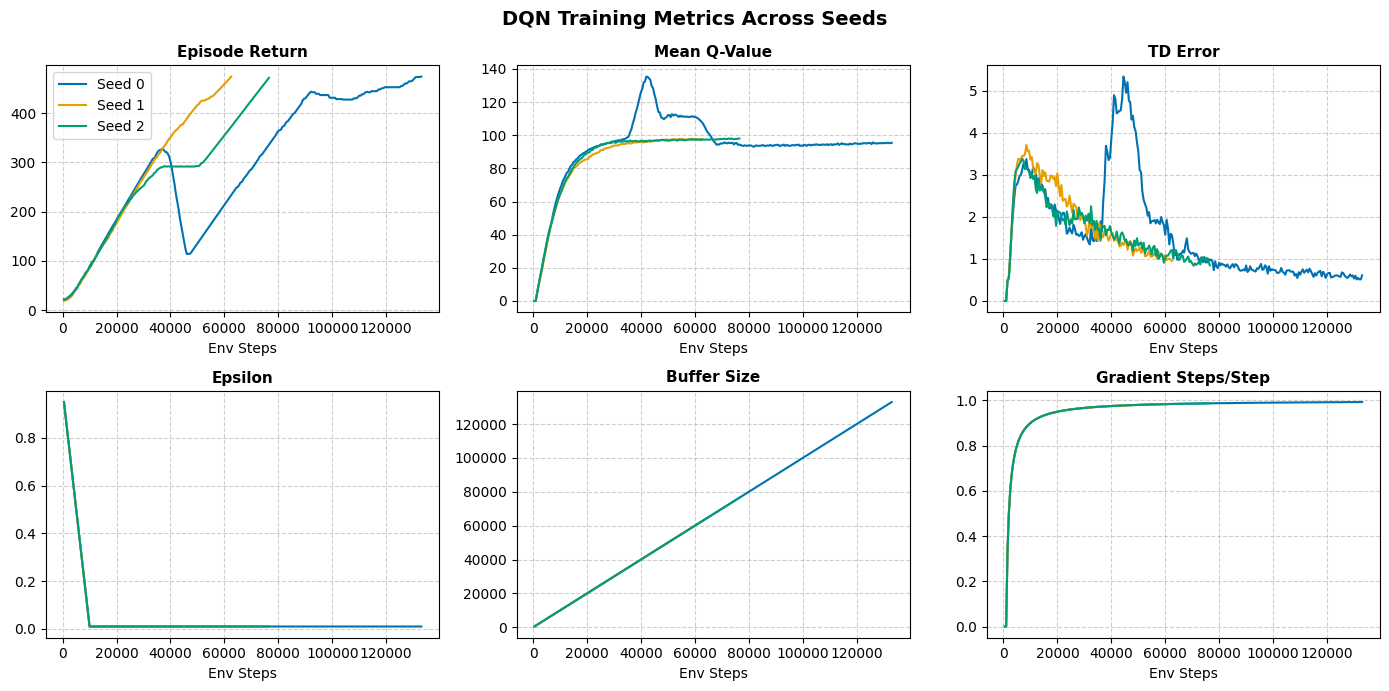

Average Inference Latency: 0.262 ms/action


In [19]:
colors = ["#0072B2", "#E69F00", "#009E73"]
metrics = ["return", "mean_q", "td_error", "epsilon", "buffer_size", "updates_per_step"]
titles = ["Episode Return", "Mean Q-Value", "TD Error", "Epsilon", "Buffer Size", "Gradient Steps/Step"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    for run_idx, res in enumerate(results):
        ax.plot(res["history"]["step"], res["history"][metric],
                color=colors[run_idx % len(colors)], label=f"Seed {res['seed']}")

    ax.set_title(titles[i], fontsize=11, fontweight="bold")
    ax.set_xlabel("Env Steps")
    ax.grid(True, linestyle="--", alpha=0.6)

axes[0].legend(loc="upper left")
fig.suptitle("DQN Training Metrics Across Seeds", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

final_latencies = [r["history"]["infer_ms"][-1] for r in results if r["history"]["infer_ms"]]
if final_latencies:
    print(f"Average Inference Latency: {np.mean(final_latencies):.3f} ms/action")